<a href="https://colab.research.google.com/github/Victand/api_purchase_predict/blob/staging/InstantMesh_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
"""InstantMesh - Corrigé (Version Finale)"""

import os
import shutil
from IPython.display import display, Video

# =========================================================
# 1. PRÉPARATION ET INSTALLATION DES DÉPENDANCES
# =========================================================

%cd /content

# Nettoyage en cas de relance de la cellule
if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

# Clonage du dépôt principal InstantMesh
!GIT_LFS_SKIP_SMUDGE=1 git clone -b dev https://github.com/camenduru/InstantMesh
%cd /content/InstantMesh

# 1. LE FIX CRUCIAL : On force numpy en version 1.x AVANT tout le reste
!pip install "numpy<2.0.0"

# 2. Installation de l'environnement GPU et utilitaires 3D
!pip install onnxruntime-gpu ninja
!pip install PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg] jax==0.4.19 jaxlib==0.4.19

# 3. Écosystème Machine Learning
!pip install pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard

# 4. Écosystème HuggingFace
!pip install "huggingface-hub<1.0" "transformers>=4.41.0" "diffusers>=0.27.0"

# 5. Configuration stricte de CUDA pour la compilation
os.environ['CUDA_HOME'] = '/usr/local/cuda'
os.environ['PATH'] += ':/usr/local/cuda/bin'
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'

# 6. FIX NVDIFRAST : Clonage et installation manuelle SANS isolation
%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git
%cd /content/nvdiffrast
!pip install --no-build-isolation .

# 7. Retour au dossier de travail principal
%cd /content/InstantMesh
print("\n=== INSTALLATION TERMINÉE AVEC SUCCÈS ===")

/content
Cloning into 'InstantMesh'...
remote: Enumerating objects: 223, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 223 (delta 76), reused 64 (delta 64), pack-reused 111 (from 1)
Receiving objects: 100% (223/223), 31.81 MiB | 13.45 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/InstantMesh
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.4/339.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 73.9 MB

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.9/776.9 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.2/299.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.2 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.5 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
  Attempting uninstall: pillow
    Found existing installation: pillow 

INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall:

In [2]:
!pip install "cupy-cuda12x<14.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: cupy-cuda12x
    Found existing installation: cupy-cuda12x 14.0.1
    Uninstalling cupy-cuda12x-14.0.1:
      Successfully uninstalled cupy-cuda12x-14.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [1]:
!pip uninstall -y flax

Found existing installation: flax 0.11.2
Uninstalling flax-0.11.2:
  Successfully uninstalled flax-0.11.2


/content/InstantMesh


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json: 0.00B [00:00, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/369 [00:00<?, ?B/s]

...

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42


  0%|          | 0/75 [00:00<?, ?it/s]

=== Images Multi-vues générées ===


/tmp/ipykernel_20408/4113691126.py:51: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  show_image = torch.from_numpy(show_image)     # (960, 640, 3)


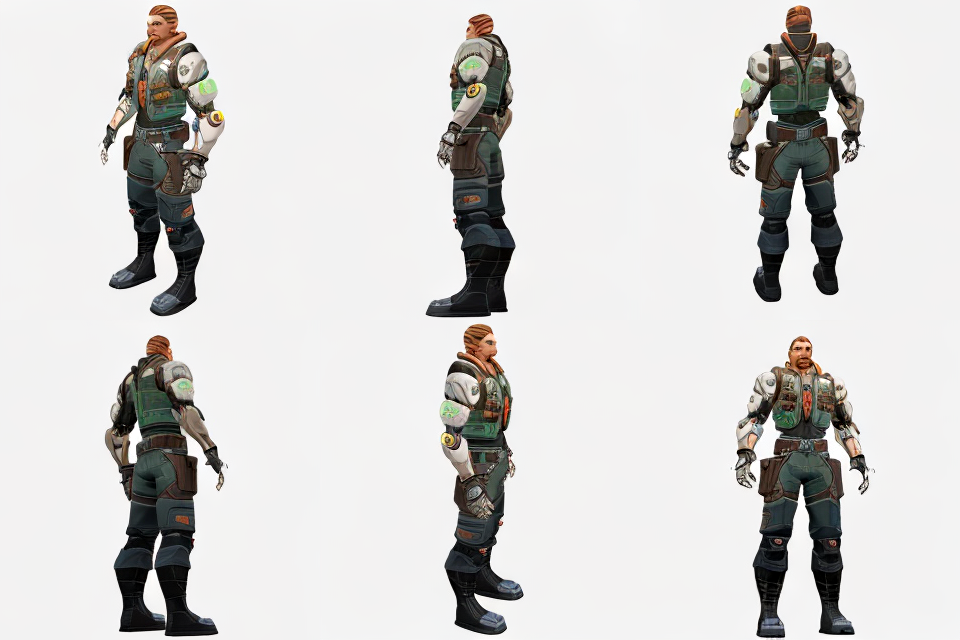

In [2]:
# =========================================================
# 2. GÉNÉRATION DES MULTI-VUES (Zero123++)
# =========================================================
%cd /content/InstantMesh

import torch
torch.cuda.empty_cache()

import numpy as np
import rembg
from PIL import Image
from pytorch_lightning import seed_everything
from einops import rearrange
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler
from huggingface_hub import hf_hub_download
from src.utils.infer_util import remove_background, resize_foreground

pipeline = DiffusionPipeline.from_pretrained(
    "sudo-ai/zero123plus-v1.2",
    custom_pipeline="zero123plus",
    torch_dtype=torch.float16,
    trust_remote_code=True
)
pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(pipeline.scheduler.config, timestep_spacing='trailing')

unet_ckpt_path = hf_hub_download(repo_id="TencentARC/InstantMesh", filename="diffusion_pytorch_model.bin", repo_type="model")
state_dict = torch.load(unet_ckpt_path, map_location='cpu')
pipeline.unet.load_state_dict(state_dict, strict=True)

device = torch.device('cuda')
pipeline = pipeline.to(device)
seed_everything(0)

def preprocess(input_image, do_remove_background):
    rembg_session = rembg.new_session() if do_remove_background else None
    if do_remove_background:
        input_image = remove_background(input_image, rembg_session)
        input_image = resize_foreground(input_image, 0.85)
    return input_image

def generate_mvs(input_image, sample_steps, sample_seed):
    seed_everything(sample_seed)
    generator = torch.Generator(device=device)
    z123_image = pipeline(
        input_image,
        num_inference_steps=sample_steps,
        generator=generator,
    ).images[0]

    show_image = np.asarray(z123_image, dtype=np.uint8)
    show_image = torch.from_numpy(show_image)     # (960, 640, 3)
    show_image = rearrange(show_image, '(n h) (m w) c -> (n m) h w c', n=3, m=2)
    show_image = rearrange(show_image, '(n m) h w c -> (n h) (m w) c', n=2, m=3)
    show_image = Image.fromarray(show_image.numpy())
    return z123_image, show_image

# Exécution partie 1
input_image_path = '/content/InstantMesh/examples/warrior.png'
input_image = Image.open(input_image_path)
processed_image = preprocess(input_image, True)

mv_images, mv_show_images = generate_mvs(processed_image, 75, 42)
mv_images.save('/content/InstantMesh/mv_images.png')

print("=== Images Multi-vues générées ===")
display(mv_show_images)


In [7]:

# =========================================================
# 3. GÉNÉRATION DU MODÈLE 3D (InstantMesh)
# =========================================================

import os

# On libère la VRAM du modèle de diffusion pour faire de la place
# del pipeline
torch.cuda.empty_cache()

from torchvision.transforms import v2
from omegaconf import OmegaConf
from einops import repeat
import tempfile
from tqdm import tqdm
import imageio
from IPython.display import display, Video

from src.utils.train_util import instantiate_from_config
from src.utils.camera_util import FOV_to_intrinsics, get_zero123plus_input_cameras, get_circular_camera_poses
from src.utils.mesh_util import save_obj, save_obj_with_mtl

config_path = 'configs/instant-mesh-base.yaml'
config = OmegaConf.load(config_path)
config_name = os.path.basename(config_path).replace('.yaml', '')

model_config = config.model_config
infer_config = config.infer_config
model_ckpt_path = hf_hub_download(repo_id="TencentARC/InstantMesh", filename="instant_mesh_base.ckpt", repo_type="model")

model = instantiate_from_config(model_config)
state_dict = torch.load(model_ckpt_path, map_location='cpu')['state_dict']
state_dict = {k[14:]: v for k, v in state_dict.items() if k.startswith('lrm_generator.') and 'source_camera' not in k}
model.load_state_dict(state_dict, strict=True)
model = model.to(device)

IS_FLEXICUBES = True if config_name.startswith('instant-mesh') else False
if IS_FLEXICUBES:
    model.init_flexicubes_geometry(device, fovy=30.0)
model = model.eval()

def images_to_video(images, output_path, fps=30):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    frames = []
    for i in range(images.shape[0]):
        frame = (images[i].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).clip(0, 255)
        frames.append(frame)
    imageio.mimwrite(output_path, np.stack(frames), fps=fps, codec='h264')

def get_render_cameras(batch_size=1, M=120, radius=2.5, elevation=10.0, is_flexicubes=False):
    c2ws = get_circular_camera_poses(M=M, radius=radius, elevation=elevation)
    if is_flexicubes:
        cameras = torch.linalg.inv(c2ws)
        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)
    else:
        extrinsics = c2ws.flatten(-2)
        intrinsics = FOV_to_intrinsics(30.0).unsqueeze(0).repeat(M, 1, 1).float().flatten(-2)
        cameras = torch.cat([extrinsics, intrinsics], dim=-1)
        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1)
    return cameras

def make_mesh(mesh_fpath, planes):
    mesh_basename = os.path.basename(mesh_fpath).split('.')[0]
    mesh_dirname = os.path.dirname(mesh_fpath)
    with torch.no_grad():
        mesh_out = model.extract_mesh(planes, use_texture_map=True, **infer_config)
        vertices, faces, uvs, mesh_tex_idx, tex_map = mesh_out
        save_obj_with_mtl(
            vertices.data.cpu().numpy(),
            uvs.data.cpu().numpy(),
            faces.data.cpu().numpy(),
            mesh_tex_idx.data.cpu().numpy(),
            tex_map.permute(1, 2, 0).data.cpu().numpy(),
            mesh_fpath,
        )
        print(f"Maillage avec texture sauvegardé sous {mesh_fpath}")
    return mesh_fpath

def make3d(images):
    images = np.asarray(images, dtype=np.float32) / 255.0
    images = torch.from_numpy(images).permute(2, 0, 1).contiguous().float()
    images = rearrange(images, 'c (n h) (m w) -> (n m) c h w', n=3, m=2)

    input_cameras = get_zero123plus_input_cameras(batch_size=1, radius=4.0).to(device)
    render_cameras = get_render_cameras(batch_size=1, radius=4.5, elevation=20.0, is_flexicubes=IS_FLEXICUBES).to(device)
    images = images.unsqueeze(0).to(device)
    images = v2.functional.resize(images, (320, 320), interpolation=3, antialias=True).clamp(0, 1)

    directory = '/content/tmp'
    os.makedirs(directory, exist_ok=True)
    tempfile.tempdir = directory
    mesh_fpath = tempfile.NamedTemporaryFile(suffix=".obj", delete=False).name

    mesh_basename = os.path.basename(mesh_fpath).split('.')[0]
    mesh_dirname = os.path.dirname(mesh_fpath)
    video_fpath = os.path.join(mesh_dirname, f"{mesh_basename}.mp4")

    with torch.no_grad():
        planes = model.forward_planes(images, input_cameras)
        chunk_size = 20 if IS_FLEXICUBES else 1
        render_size = 384
        frames = []
        for i in tqdm(range(0, render_cameras.shape[1], chunk_size)):
            if IS_FLEXICUBES:
                frame = model.forward_geometry(planes, render_cameras[:, i:i+chunk_size], render_size=render_size)['img']
            else:
                frame = model.synthesizer(planes, cameras=render_cameras[:, i:i+chunk_size], render_size=render_size)['images_rgb']
            frames.append(frame)

        frames = torch.cat(frames, dim=1)
        images_to_video(frames[0], video_fpath, fps=30)
        print(f"Vidéo de prévisualisation sauvegardée sous {video_fpath}")

    mesh_fpath = make_mesh(mesh_fpath, planes)
    return video_fpath, mesh_fpath

# Exécution partie 2
mv_images = Image.open('/content/InstantMesh/mv_images.png')
output_video, output_model_obj = make3d(mv_images)

!cp -f {output_video} /content/InstantMesh/output_video.mp4
!cp -f {output_model_obj} /content/InstantMesh/output_model.obj

print("=== Prévisualisation 3D ===")
display(Video('/content/InstantMesh/output_video.mp4', embed=True))


video_path = '/content/InstantMesh/output_video.mp4'

if os.path.exists(video_path):
    print("🎬 Affichage de la vidéo 3D en cours...")
    display(Video(video_path, embed=True, width=512))
else:
    print("❌ Erreur : Le fichier vidéo n'a pas été trouvé. Assure-toi que la génération s'est bien terminée.")

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['encoder.layer.0.adaLN_modulation.1.bias', 'encoder.layer.0.adaLN_modulation.1.weight', 'encoder.layer.1.adaLN_modulation.1.bias', 'encoder.layer.1.adaLN_modulation.1.weight', 'encoder.layer.10.adaLN_modulation.1.bias', 'encoder.layer.10.adaLN_modulation.1.weight', 'encoder.layer.11.adaLN_modulation.1.bias', 'encoder.layer.11.adaLN_modulation.1.weight', 'encoder.layer.2.adaLN_modulation.1.bias', 'encoder.layer.2.adaLN_modulation.1.weight', 'encoder.layer.3.adaLN_modulation.1.bias', 'encoder.layer.3.adaLN_modulation.1.weight', 'encoder.layer.4.adaLN_modulation.1.bias', 'encoder.layer.4.adaLN_modulation.1.weight', 'encoder.layer.5.adaLN_modulation.1.bias', 'encoder.layer.5.adaLN_modulation.1.weight', 'encoder.layer.6.adaLN_modulation.1.bias', 'encoder.layer.6.adaLN_modulation.1.weight', 'encoder.layer.7.adaLN_modulation.1.bias', 'encoder.layer.7.adaLN_modulation.1.w

Vidéo de prévisualisation sauvegardée sous /content/tmp/tmp07c5ovyo.mp4
Maillage avec texture sauvegardé sous /content/tmp/tmp07c5ovyo.obj
=== Prévisualisation 3D ===


🎬 Affichage de la vidéo 3D en cours...
